# Modeling notebook for the computacional variables
---

## The models which were used:
- Ridge
- RandomForest (with two criterions)
- LGBMRegressor

## The metrics to evaluate the models were:
- Root Mean Squared Error (`RMSE`)
- Mean Absolute Error (`MAE`)
- Weight Absolute Percentual Error (`WAPE`)

In [1]:
# ! pip install lightgbm

In [2]:
import pandas as pd
import numpy as np

# from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [3]:
from pipeline_datapreparation import prepare_datasets as DataPipeline

In [4]:
def plot_metric_comparison(train, test, title):
    train = pd.DataFrame(train)
    test = pd.DataFrame(test)
    metrics = train.index
    models = train.columns

    colors = {"Treino": "#8E9091", "Teste": "#5B8CC0"}

    x = np.arange(len(models))
    width = 0.35

    fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5), dpi=500)

    for i, metric in enumerate(metrics):
        ax = axes[i]

        train_values = train.loc[metric]
        test_values = test.loc[metric]

        bars_train = ax.bar(x - width/2, train_values, width, color=colors['Treino'], label='Treino')
        bars_test = ax.bar(x + width/2, test_values, width, color=colors['Teste'], label='Teste')
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)

        for bar in bars_train:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height,
                    f'{height:.3f}', ha='center', va='bottom')
        
        for bar in bars_test:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height,
                    f'{height:.3f}', ha='center', va='bottom')
# fontsize=12, fontweight="bold", pad=10
        ax.set_title(metric.upper(), fontdict=dict(fontsize=12, fontweight="bold"), pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=0)
        ax.set_ylabel(metric.upper())

    # axes[0].legend()  # legenda só no primeiro para evitar repetição

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        frameon=False,
    )
    
    fig.suptitle(
        title,
        fontsize=14,
        fontweight="bold",
        y=1.08,
    )

    plt.tight_layout()
    plt.show()
    return fig

In [5]:
def regression_metrics(y_true, y_pred):
    rmse = round(np.sqrt(mean_squared_error(y_true, y_pred)), 3)
    mae = round(mean_absolute_error(y_true, y_pred), 3)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    wape = np.sum(np.abs(y_true - y_pred)) / denom
    return {'rmse':rmse, 'mae':mae, 'wape':round(wape, 3)}

In [6]:
datasets = {
    "train": pd.read_csv("dados/train.csv"),
    "test": pd.read_csv("dados/test.csv")
}

prepared = DataPipeline(
    datasets,
    treat_outliers=True,
    create_lags=True,
    stationary=False
)

print("Conjunto de Treino")
df_train = prepared["train"]["prepared_data"]
display(df_train.head())

print("Conjunto de Teste")
df_test = prepared["test"]["prepared_data"].iloc[12:]
display(df_test.head())

print(f"Shape conjunto de treino: {df_train.shape}")
print(f"Shape conjunto de teste: {df_test.shape}")

Conjunto de Treino


,PCEPI_fred-md,UNETOT_PT_ea-md,CCI_PT_ea-md,IMPGS_PT_ea-qd,EXPGS_PT_ea-qd,GS5_fred-md,CCONFIX_PT_ea-md,EMPENT_PT_ea-qd,GS1_fred-md,HICPSV_PT_ea-md,...,OILPRICEx_fred-md_Eur_lag_2,OILPRICEx_fred-md_Eur_lag_3,OILPRICEx_fred-md_Eur_lag_4,OILPRICEx_fred-md_Eur_lag_5,OILPRICEx_fred-md_Eur_lag_6,OILPRICEx_fred-md_Eur_lag_7,OILPRICEx_fred-md_Eur_lag_12,inflation_target_lag_1,inflation_target_lag_2,inflation_target_lag_3
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,-1.672367,-1.181375,1.622256,-1.292769,-1.333886,2.651460,1.612561,-1.857311,2.370485,-2.090914,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-02-01,-1.652773,-1.239516,1.555927,-1.236718,-1.348727,2.718651,1.557800,-1.854323,2.425870,-2.082324,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.1,NaN,NaN
2000-03-01,-1.626023,-1.268586,1.417198,-1.176579,-1.373899,2.597707,1.539546,-1.838577,2.425870,-2.075948,...,-1.466960,NaN,NaN,NaN,NaN,NaN,NaN,1.8,2.1,NaN
2000-04-01,-1.631220,-1.297657,1.212752,-1.142906,-1.394979,2.436448,0.991927,-1.805954,2.387100,-2.069746,...,-1.118196,-1.466960,NaN,NaN,NaN,NaN,NaN,1.5,1.8,2.1
2000-05-01,-1.626023,-1.268586,1.103049,-1.145707,-1.402864,2.725370,1.101451,-1.761853,2.486794,-2.054342,...,-0.958600,-1.118196,-1.46696,NaN,NaN,NaN,NaN,2.1,1.5,1.8


Conjunto de Teste


,PCEPI_fred-md,UNETOT_PT_ea-md,CCI_PT_ea-md,IMPGS_PT_ea-qd,EXPGS_PT_ea-qd,GS5_fred-md,CCONFIX_PT_ea-md,EMPENT_PT_ea-qd,GS1_fred-md,HICPSV_PT_ea-md,...,OILPRICEx_fred-md_Eur_lag_2,OILPRICEx_fred-md_Eur_lag_3,OILPRICEx_fred-md_Eur_lag_4,OILPRICEx_fred-md_Eur_lag_5,OILPRICEx_fred-md_Eur_lag_6,OILPRICEx_fred-md_Eur_lag_7,OILPRICEx_fred-md_Eur_lag_12,inflation_target_lag_1,inflation_target_lag_2,inflation_target_lag_3
Date,,,,,,,,,,,,,,,,,,,,,
2023-07-01,2.386643,-0.948811,-0.212584,2.307421,2.135289,1.011992,-0.075929,2.574181,1.955093,2.146303,...,0.775336,1.009704,0.798917,1.009527,0.981243,0.960468,2.373517,3.4,4.0,5.7
2023-08-01,2.417567,-0.948811,-0.289823,2.324309,2.090561,1.126217,-0.176325,2.599608,1.955093,2.224553,...,0.666480,0.775336,1.009704,0.798917,1.009527,0.981243,2.153891,3.1,3.4,4.0
2023-09-01,2.455818,-0.890670,-0.507197,2.351462,2.066858,1.247161,-0.577912,2.645049,1.993863,2.160515,...,0.837010,0.666480,0.775336,1.009704,0.798917,1.009527,1.915145,3.7,3.1,3.4
2023-10-01,2.461355,-0.890670,-0.693885,2.381320,2.077965,1.435297,-0.687436,2.729573,1.982785,2.176974,...,1.336650,0.837010,0.666480,0.775336,1.009704,0.798917,1.980482,3.6,3.7,3.1
2023-11-01,2.462122,-0.919741,-0.761598,2.408523,2.113032,1.247161,-0.961245,2.831292,1.905246,2.152486,...,1.848272,1.336650,0.837010,0.666480,0.775336,1.009704,1.750668,2.1,3.6,3.7


Shape conjunto de treino: (282, 86)
Shape conjunto de teste: (28, 86)


## Selecting the models

In [7]:
cols_level = [col for col in df_train.drop('inflation_target', axis=1).columns if 'lag' not in col]
target = 'inflation_target'

RANDOM_STATE = 322

models = {
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "RF - MSE": RandomForestRegressor(
        criterion='squared_error',
        random_state=RANDOM_STATE,
    ),
    "RF - MAE": RandomForestRegressor(
        criterion='absolute_error',
        random_state=RANDOM_STATE,
    ),
    "LGBMRegressor": LGBMRegressor(        
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
}

In [8]:
def build_model(variables, lag=0):
    scores_train = {}
    scores_test = {}
    predictions_test = {}

    my_models = models

    # Dados
    X_train = df_train[variables].dropna()
    y_train = df_train[target].iloc[lag:]

    X_test = df_test[variables]
    y_test = df_test[target]

    for model_name, clf in my_models.items():

        clf.fit(X_train, y_train)

        # =========================
        # TRAIN
        # =========================
        pred_train = clf.predict(X_train)

        scores_train[model_name] = regression_metrics(
            y_train,
            pred_train
        )

        # =========================
        # TEST
        # =========================
        pred_test = clf.predict(X_test)

        scores_test[model_name] = regression_metrics(
            y_test,
            pred_test
        )

        # Guardar previsões
        predictions_test[model_name] = pred_test

    return (
        scores_train,
        scores_test,
        predictions_test,
        my_models
    )


def plot_predictions(
    y_true,
    predictions,
    models_to_plot=None,
    title="Previsões vs Valores Reais"
):
    """
    y_true -> Série com valores reais
    predictions -> dicionário com previsões
    models_to_plot -> lista com modelos a visualizar
    """

    fig = go.Figure()

    # Valores reais
    fig.add_trace(
        go.Scatter(
            x=y_true.index,
            y=y_true.values,
            mode="lines",
            name="Valores Reais"
        )
    )

    # Se nenhum modelo for especificado
    if models_to_plot is None:
        models_to_plot = predictions.keys()

    # Previsões
    for model_name in models_to_plot:

        fig.add_trace(
            go.Scatter(
                x=y_true.index,
                y=predictions[model_name],
                mode="lines",
                name=model_name
            )
        )

    fig.update_layout(
        title=title,
        xaxis_title="Data",
        yaxis_title="Valor",
        template="plotly_white",
        hovermode="x unified",
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="center",
            x=0.5
        )
    )

    fig.show()

# Model with the computational variables in level

In [9]:
computational_variables = [
    'GS1_fred-md', 'GS5_fred-md', 'OILPRICEx_fred-md_Eur',
    'CUSR0000SAC_fred-md', 'PCEPI_fred-md', 'EMPENT_PT_ea-qd',
    'REER42_PT_ea-md', 'HICPOV_PT_ea-md', 'HICPNEF_PT_ea-md',
    'HICPSV_PT_ea-md', 'HICPNG_PT_ea-md', 'DFGDP_PT_ea-qd',
    'CCONFIX_PT_ea-md', "PPIPT_ppi",
]

len(computational_variables)

14

In [10]:
train, test, preds, _ = build_model(computational_variables)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.973,0.154,0.143,0.265
mae,0.770,0.110,0.108,0.170
wape,0.344,0.049,0.048,0.076


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,5.264,4.966,3.424,2.712
mae,5.195,4.917,3.247,2.605
wape,2.133,2.019,1.333,1.070


In [10]:
train, test, preds, _ = build_model(computational_variables)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,1.229,0.177,0.178,0.266
mae,0.979,0.127,0.123,0.186
wape,0.437,0.057,0.055,0.083


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,5.169,5.349,4.707,2.925
mae,4.965,5.323,4.677,2.795
wape,2.038,2.185,1.920,1.147


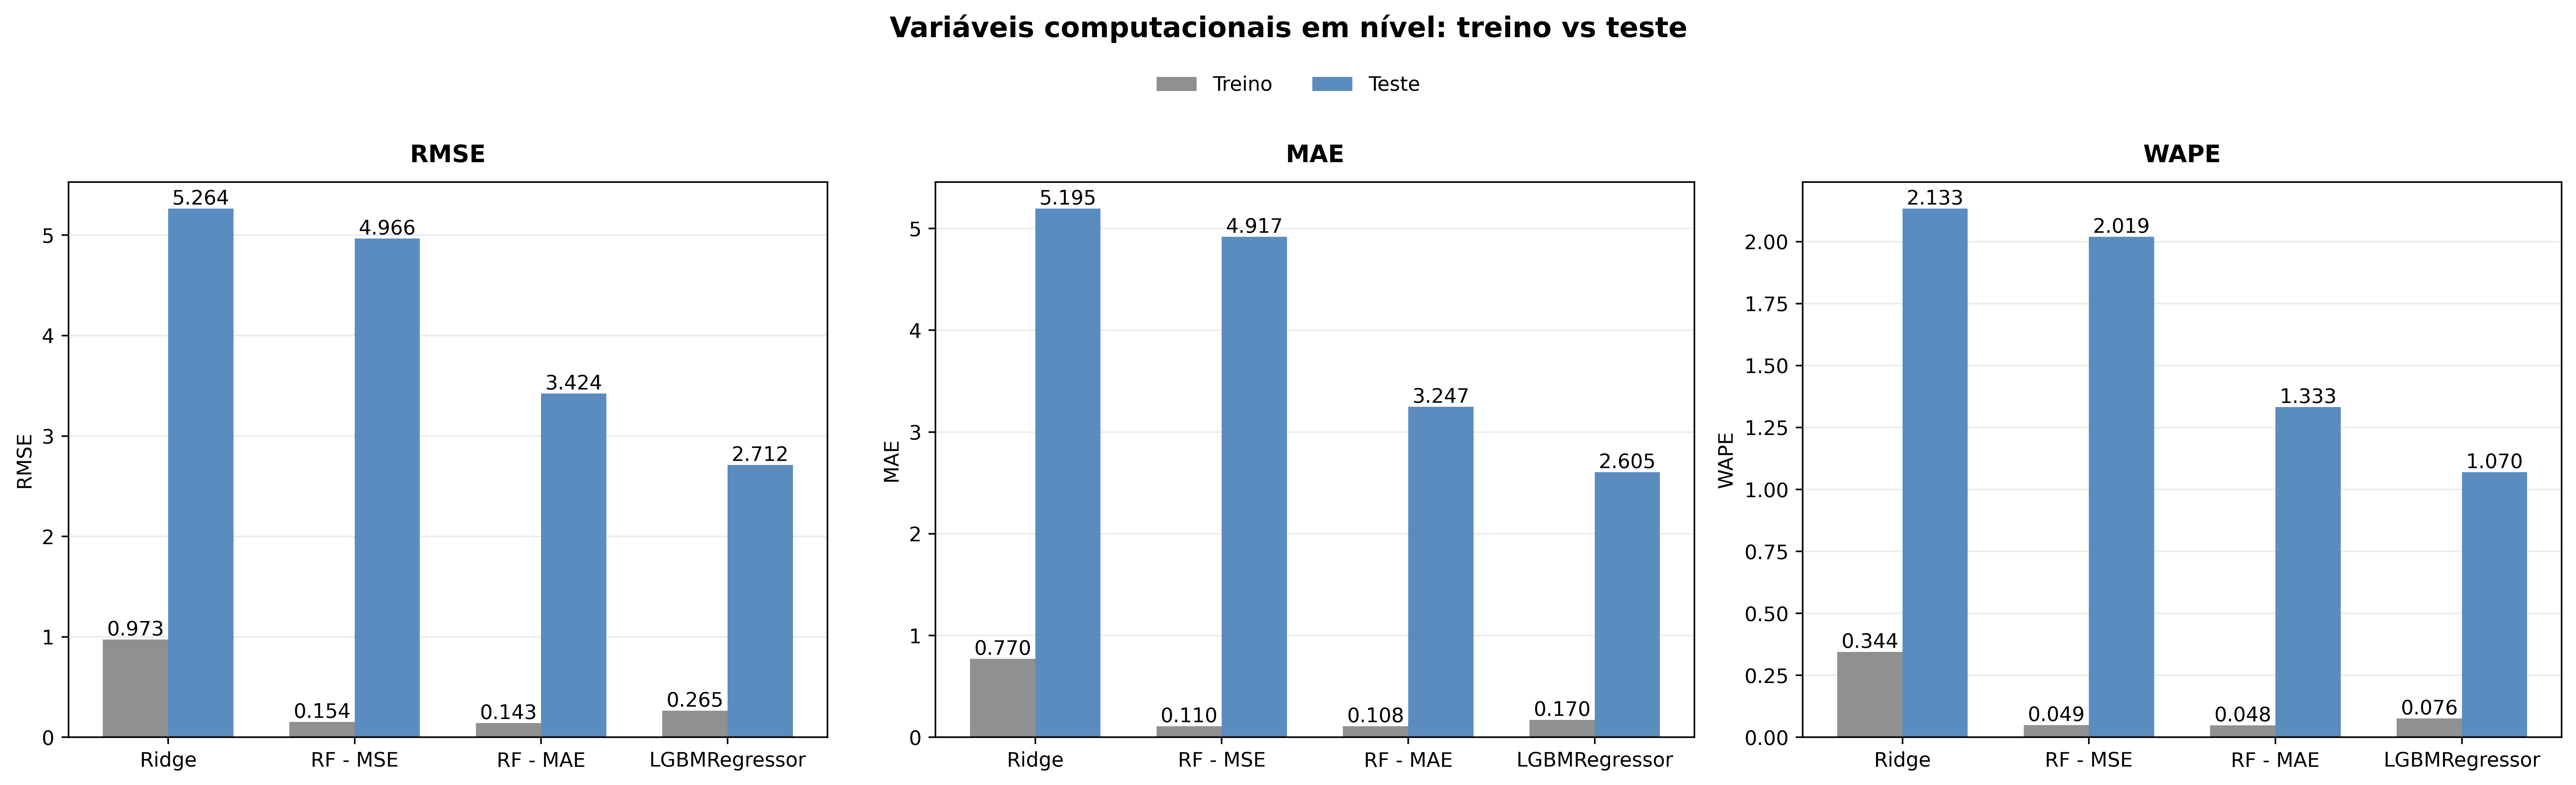

In [11]:
fig = plot_metric_comparison(train, test, "Variáveis computacionais em nível: treino vs teste")

In [12]:
fig.savefig("Imagens/Variáveis computacionais em nível.png", dpi=500, bbox_inches='tight')

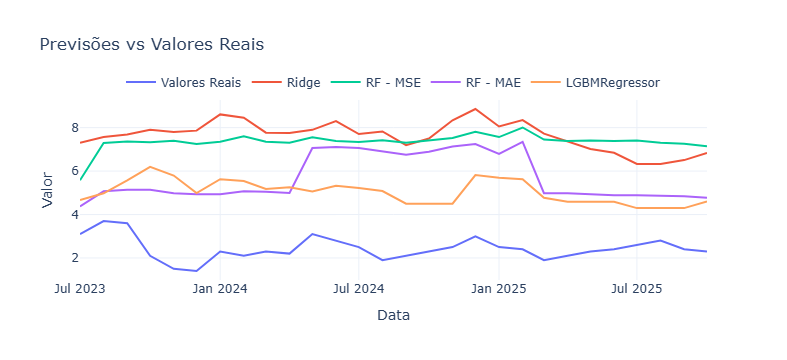

In [13]:
plot_predictions(df_test[target], preds)

## Best model with the computational variables using lags [except target lags]

In [14]:
var_lags = {'GS1_fred-md': [10],
 'GS5_fred-md': [12],
 'OILPRICEx_fred-md_Eur': [1, 2, 3, 4, 5, 6, 7, 12],
 'CUSR0000SAC_fred-md': [1, 2, 11, 12],
 'PCEPI_fred-md': [12],
 'EMPENT_PT_ea-qd': [12],
 'REER42_PT_ea-md': [6, 7, 8, 9, 10, 11, 12],
 'HICPOV_PT_ea-md': [12],
 'HICPNEF_PT_ea-md': [12],
 'HICPSV_PT_ea-md': [12],
 'HICPNG_PT_ea-md': [1, 3, 4, 12],
 'DFGDP_PT_ea-qd': [12],
 'CCONFIX_PT_ea-md': [1, 2, 11, 12],
 'epu_pt_epu': [6, 7, 8],
 'GDP_PT_ea-qd': [1, 2, 3, 4, 5, 12],
 'ULCIN_PT_ea-qd': [12],
 'EXPGS_PT_ea-qd': [12],
 'IMPGS_PT_ea-qd': [2, 3],
 'CCI_PT_ea-md': [12],
 'UNETOT_PT_ea-md': [12],
 'PPIPT_ppi': [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12]}


In [15]:
def get_lags(variables, lags):
    my_lags = list()
    for key, value in var_lags.items():
        if key in variables:
            for v in value:
                if v <= lags:
                    my_lags.append(f'{key}_lag_{v}')

    return my_lags

In [16]:
def rank_models_by_average_test_rank(lag_performance_df):
    ranked_df = lag_performance_df.copy()

    ranked_df["rank_test_wape"] = ranked_df["test_wape"].rank(
        method="min",
        ascending=True,
    )

    ranked_df["rank_test_rmse"] = ranked_df["test_rmse"].rank(
        method="min",
        ascending=True,
    )

    ranked_df["rank_test_mae"] = ranked_df["test_mae"].rank(
        method="min",
        ascending=True,
    )

    ranked_df["Overfitting?"] = (
        ranked_df["test_mae"] > ranked_df["train_mae"] * 2
        ) | (
        ranked_df["test_rmse"] > ranked_df["train_rmse"] * 2
        )

    ranked_df["rank_medio"] = ranked_df[
        ["rank_test_wape", "rank_test_rmse", "rank_test_mae"]
    ].mean(axis=1)

    ranked_df = (
        ranked_df
        .sort_values(["rank_medio", "test_rmse", "test_mae"])
        .reset_index(drop=True)
    )

    return ranked_df

In [17]:
def plot_top5_lag_model_metrics(lag_performance_ranked_df):
    top5_models = lag_performance_ranked_df.head(5).copy()

    metric_labels = ["MAE", "RMSE", "WAPE"]
    train_cols = ["train_mae", "train_rmse", "train_wape"]
    test_cols = ["test_mae", "test_rmse", "test_wape"]

    for _, row in top5_models.iterrows():
        model_name = row["model"]
        lag = row["lag"]
        overfitting = row["Overfitting?"]

        train_values = [row[col] for col in train_cols]
        test_values = [row[col] for col in test_cols]

        x = np.arange(len(metric_labels))
        width = 0.35

        fig, ax = plt.subplots(figsize=(10, 6))

        bars_train = ax.bar(
            x - width / 2,
            train_values,
            width,
            label="treino fitted",
            color="#5B7DBE",
        )

        bars_test = ax.bar(
            x + width / 2,
            test_values,
            width,
            label="teste forecast",
            color="#E88B39",
        )

        ax.set_title(f"{model_name} - lag {lag}: Treino vs Teste (Overfitting? - {overfitting})", fontsize=14)
        ax.set_ylabel("Valor")
        ax.set_xticks(x)
        ax.set_xticklabels(metric_labels)
        ax.grid(axis="y", alpha=0.4, linestyle="--")
        ax.legend()

        for bars in [bars_train, bars_test]:
            for bar in bars:
                height = bar.get_height()
                bar_color = bar.get_facecolor()

                ax.annotate(
                    f"{height:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    fontweight="bold",
                    color=bar_color,
                )

        fig.tight_layout()
        plt.show()

In [18]:
lag_performance = {}

for lag in range(1, 13):
    my_lags1 = get_lags(computational_variables, lag)
    scores_train, scores_test, preds, _ = build_model(computational_variables + my_lags1, lag)

    lag_performance[lag] = {
        "train": scores_train,
        "test": scores_test,
    }

lag_performance_rows = []

for lag, lag_results in lag_performance.items():
    for model_name in lag_results["train"].keys():
        row = {
            "lag": lag,
            "model": model_name,
            "train_wape": lag_results["train"][model_name]["wape"],
            "train_rmse": lag_results["train"][model_name]["rmse"],
            "train_mae": lag_results["train"][model_name]["mae"],
            "test_wape": lag_results["test"][model_name]["wape"],
            "test_rmse": lag_results["test"][model_name]["rmse"],
            "test_mae": lag_results["test"][model_name]["mae"],
        }

        lag_performance_rows.append(row)

lag_performance_df = pd.DataFrame(lag_performance_rows)
print("Primeiros modelos construídos:")
display(lag_performance_df.head(4))

lag_performance_ranked_df = rank_models_by_average_test_rank(lag_performance_df)
print("Top 4 melhores modelos:")
display(lag_performance_ranked_df.head(4))

Primeiros modelos construídos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae
0,1,Ridge,0.337,0.944,0.756,1.866,4.629,4.545
1,1,RF - MSE,0.046,0.137,0.102,1.812,4.550,4.413
2,1,RF - MAE,0.049,0.143,0.110,1.103,3.025,2.686
3,1,LGBMRegressor,0.067,0.236,0.150,1.078,2.741,2.626


Top 4 melhores modelos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae,rank_test_wape,rank_test_rmse,rank_test_mae,Overfitting?,rank_medio
0,11,LGBMRegressor,0.042,0.158,0.094,0.203,0.653,0.494,1.0,1.0,1.0,True,1.000000
1,10,LGBMRegressor,0.046,0.163,0.102,0.242,0.739,0.589,2.0,2.0,2.0,True,2.000000
2,12,LGBMRegressor,0.039,0.150,0.086,0.318,0.948,0.774,3.0,3.0,3.0,True,3.000000
3,9,LGBMRegressor,0.044,0.158,0.097,0.398,1.107,0.971,4.0,5.0,4.0,True,4.333333


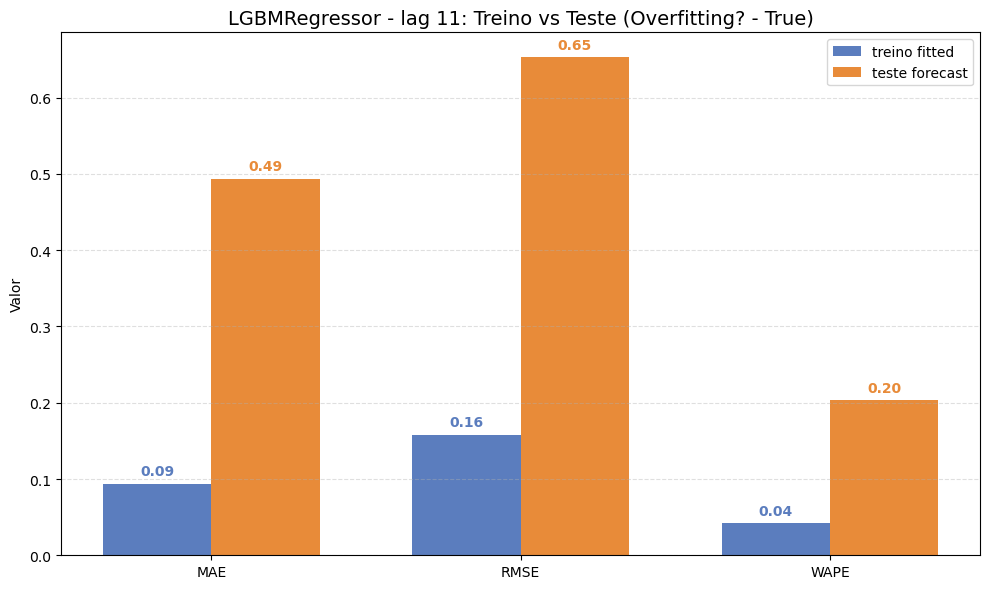

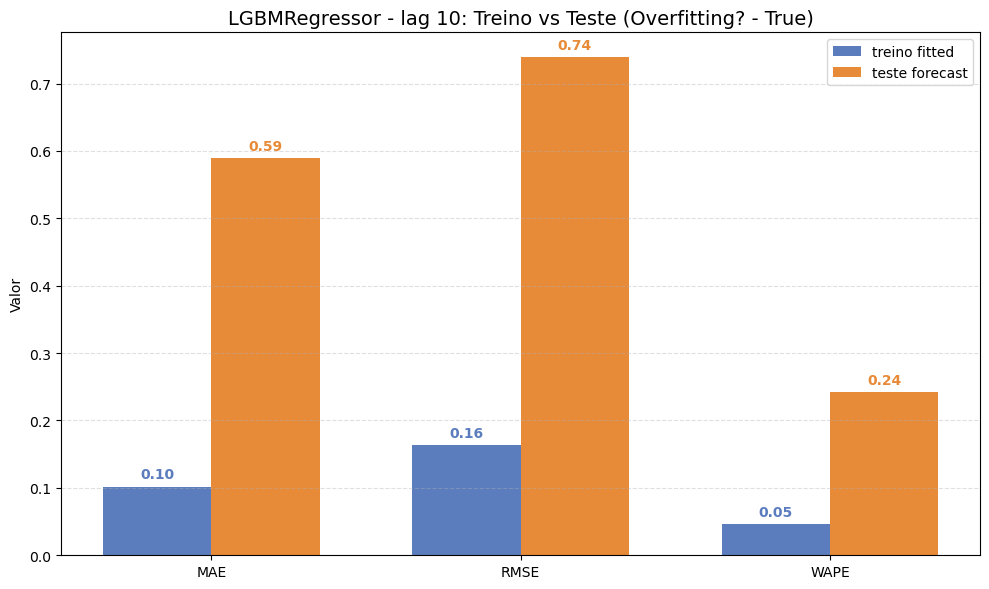

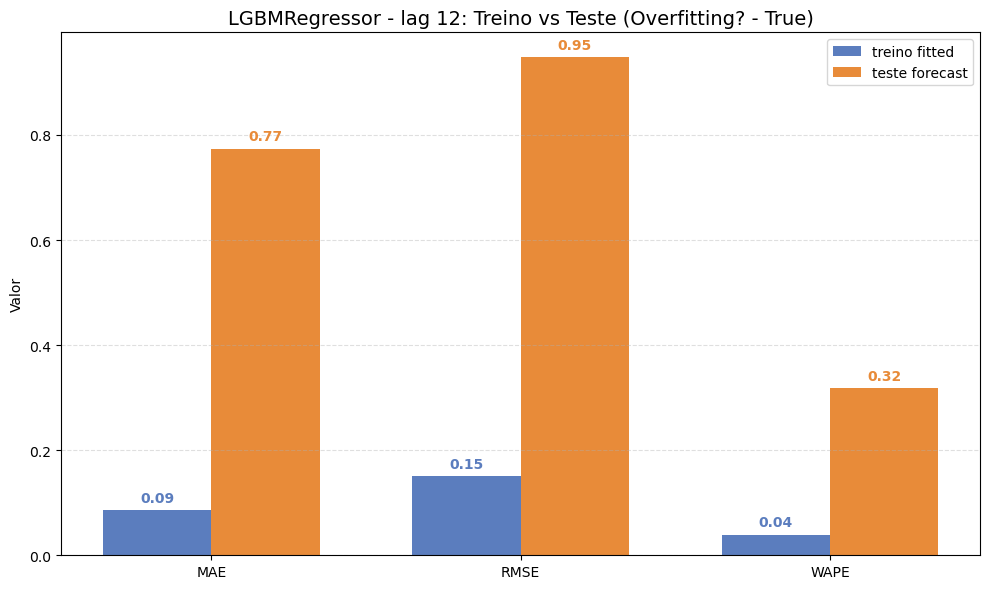

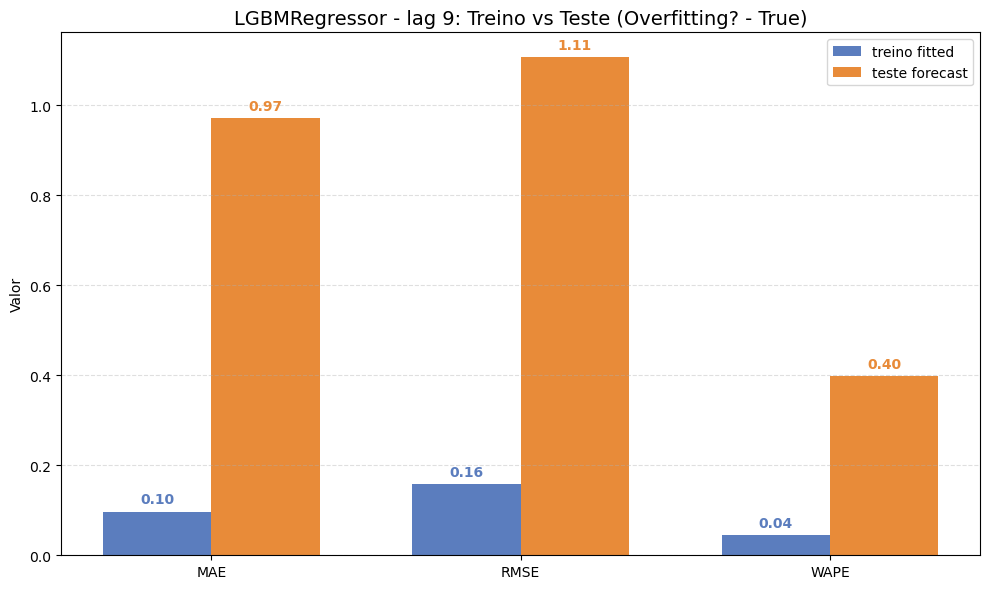

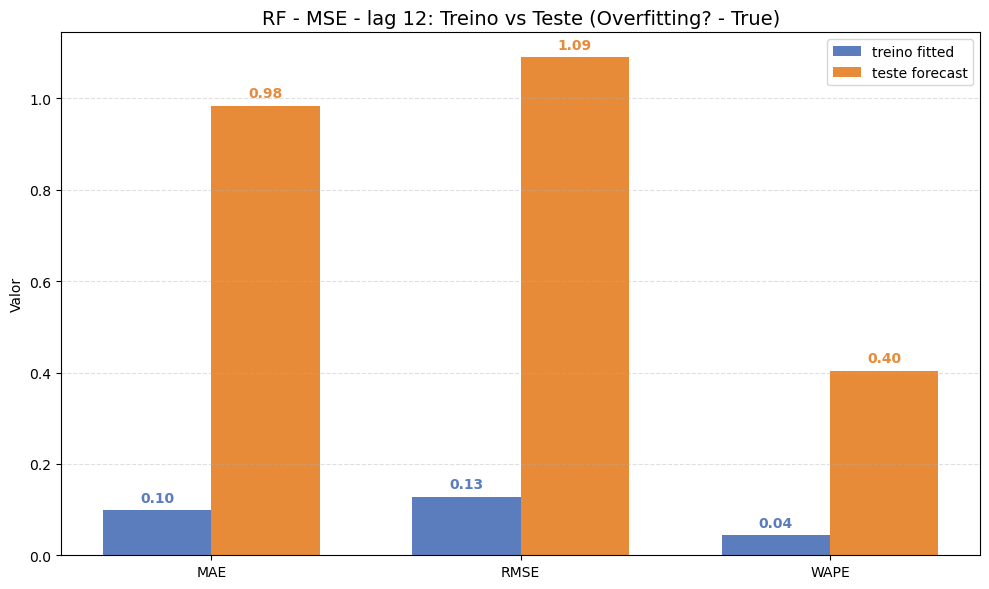

In [19]:
plot_top5_lag_model_metrics(lag_performance_ranked_df)

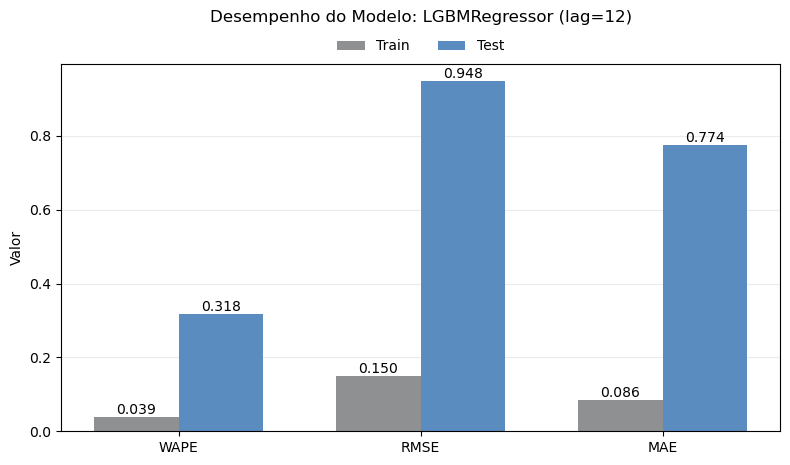

In [20]:
def plot_single_model_performance(row, path):
    metrics = ['wape', 'rmse', 'mae']

    colors = {"Treino": "#8E9091", "Teste": "#5B8CC0"}
    
    train_values = [row[f'train_{m}'] for m in metrics]
    test_values = [row[f'test_{m}'] for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars_train = ax.bar(x - width/2, train_values, width, label='Train', color=colors["Treino"])
    bars_test = ax.bar(x + width/2, test_values, width, label='Test', color=colors["Teste"])

    ax.set_xticks(x, [m.upper() for m in metrics])
    ax.set_ylabel('Valor')
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_title(f"Desempenho do Modelo: {row['model']} (lag={row['lag']})", pad=30)
    # ax.legend()

    # Valores por cima das barras
    for bar in list(bars_train) + list(bars_test):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.3f}', ha='center', va='bottom')

    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.10),
        ncol=2,
        frameon=False,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(f"Imagens/{path}.png", dpi=500, bbox_inches='tight')

plot_single_model_performance(lag_performance_ranked_df.iloc[2], 'melhor modelo (variáveis computacionais) sem lags da alvo')

## Model with the computational variables with the first selected lag

In [21]:
lag_min = [f'{key}_lag_{value[0]}' for key, value in var_lags.items() if key in computational_variables]
lag_min

['GS1_fred-md_lag_10',
 'GS5_fred-md_lag_12',
 'OILPRICEx_fred-md_Eur_lag_1',
 'CUSR0000SAC_fred-md_lag_1',
 'PCEPI_fred-md_lag_12',
 'EMPENT_PT_ea-qd_lag_12',
 'REER42_PT_ea-md_lag_6',
 'HICPOV_PT_ea-md_lag_12',
 'HICPNEF_PT_ea-md_lag_12',
 'HICPSV_PT_ea-md_lag_12',
 'HICPNG_PT_ea-md_lag_1',
 'DFGDP_PT_ea-qd_lag_12',
 'CCONFIX_PT_ea-md_lag_1',
 'PPIPT_ppi_lag_1']

In [22]:
train, test, preds, _ = build_model(lag_min + computational_variables, 12)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.366,0.143,0.147,0.197
mae,0.284,0.106,0.104,0.128
wape,0.128,0.048,0.047,0.058


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,1.895,4.090,2.662,2.277
mae,1.642,3.969,2.321,2.161
wape,0.674,1.630,0.953,0.887


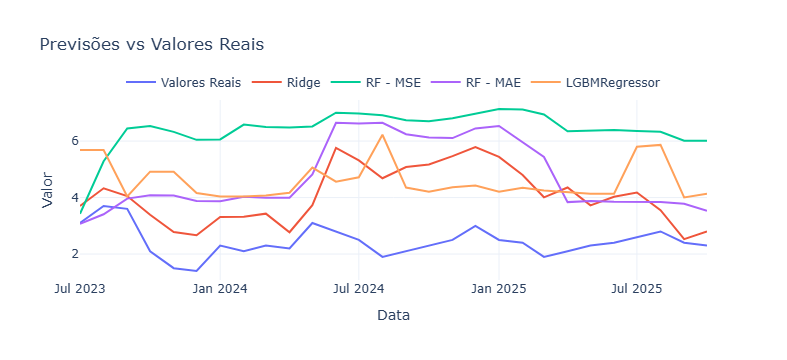

In [23]:
plot_predictions(df_test[target], preds)

## Model with the computational variables with the last selected lag

In [24]:
lag_max = [f'{key}_lag_{value[-1]}' for key, value in var_lags.items() if key in computational_variables]
lag_max

['GS1_fred-md_lag_10',
 'GS5_fred-md_lag_12',
 'OILPRICEx_fred-md_Eur_lag_12',
 'CUSR0000SAC_fred-md_lag_12',
 'PCEPI_fred-md_lag_12',
 'EMPENT_PT_ea-qd_lag_12',
 'REER42_PT_ea-md_lag_12',
 'HICPOV_PT_ea-md_lag_12',
 'HICPNEF_PT_ea-md_lag_12',
 'HICPSV_PT_ea-md_lag_12',
 'HICPNG_PT_ea-md_lag_12',
 'DFGDP_PT_ea-qd_lag_12',
 'CCONFIX_PT_ea-md_lag_12',
 'PPIPT_ppi_lag_12']

In [25]:
train, test, preds, _ = build_model(lag_max + computational_variables, 12)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.337,0.149,0.134,0.198
mae,0.274,0.106,0.100,0.118
wape,0.124,0.048,0.045,0.053


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,2.014,4.459,2.919,1.892
mae,1.878,4.417,2.735,1.733
wape,0.771,1.813,1.123,0.711


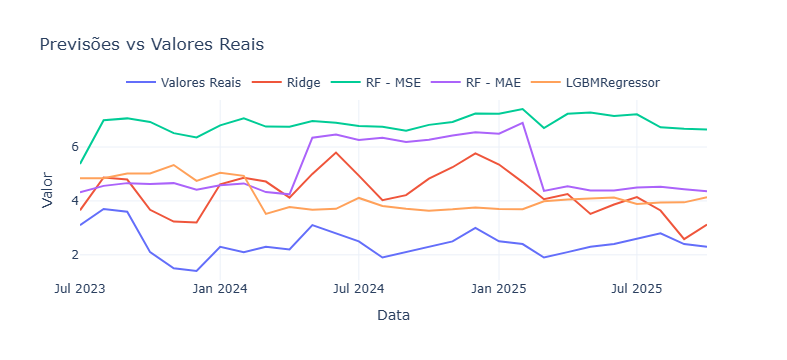

In [26]:
plot_predictions(df_test[target], preds)

# Adding target lag

## Simple model only with the first target lag

In [27]:
target_lag = ['inflation_target_lag_1',]
train, test, preds, _  = build_model(target_lag, 1)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.419,0.341,0.343,0.667
mae,0.300,0.258,0.254,0.393
wape,0.134,0.115,0.113,0.176


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.478,0.552,0.528,0.517
mae,0.363,0.418,0.398,0.391
wape,0.149,0.172,0.163,0.160


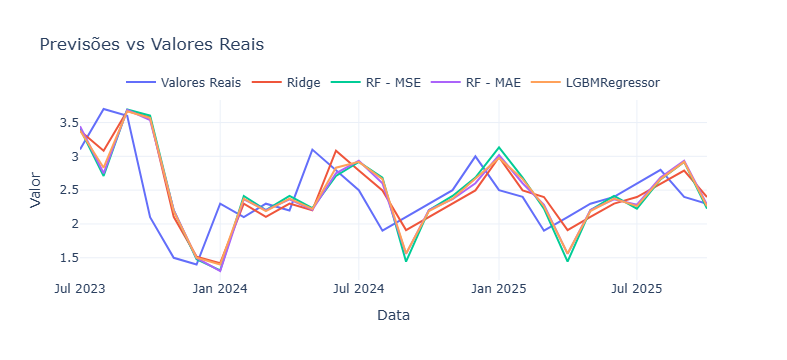

In [28]:
plot_predictions(df_test[target], preds)

## Using the first selected lags with first target lag

In [29]:
train, test, preds, _ = build_model(computational_variables + lag_min + target_lag, 12)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.264,0.143,0.143,0.199
mae,0.199,0.104,0.104,0.127
wape,0.090,0.047,0.047,0.058


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.507,3.647,2.035,0.884
mae,0.421,3.301,1.850,0.729
wape,0.173,1.355,0.760,0.299


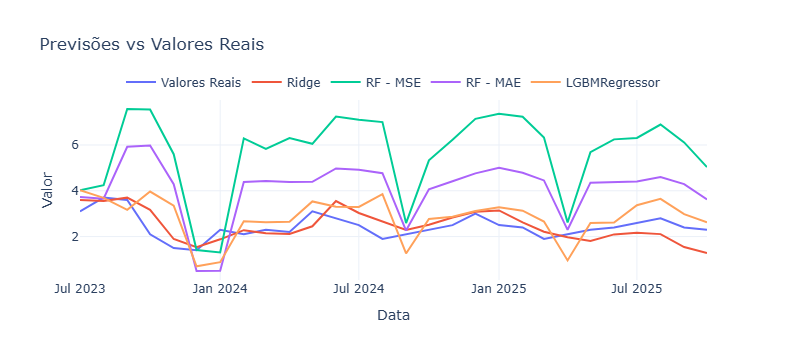

In [30]:
plot_predictions(df_test[target], preds)

## Using the last selected lags with first target lag

In [31]:
train, test, preds, _ = build_model(computational_variables + lag_max + target_lag, 12)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.241,0.147,0.146,0.202
mae,0.182,0.103,0.104,0.123
wape,0.082,0.047,0.047,0.055


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.530,2.493,1.713,0.921
mae,0.420,2.284,1.577,0.827
wape,0.172,0.938,0.648,0.340


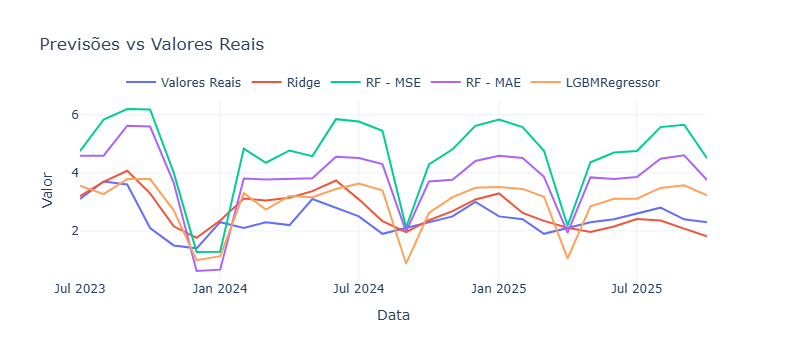

In [32]:
plot_predictions(df_test[target], preds)

## Best model with the computational variables using lags [including target lags]

In [33]:
lag_performance = {}

for lag in range(1, 13):
    my_lags1 = get_lags(computational_variables, lag)
    scores_train, scores_test, preds, _ = build_model(computational_variables + my_lags1 + target_lag, lag)

    lag_performance[lag] = {
        "train": scores_train,
        "test": scores_test,
    }

lag_performance_rows = []

for lag, lag_results in lag_performance.items():
    for model_name in lag_results["train"].keys():
        row = {
            "lag": lag,
            "model": model_name,
            "train_wape": lag_results["train"][model_name]["wape"],
            "train_rmse": lag_results["train"][model_name]["rmse"],
            "train_mae": lag_results["train"][model_name]["mae"],
            "test_wape": lag_results["test"][model_name]["wape"],
            "test_rmse": lag_results["test"][model_name]["rmse"],
            "test_mae": lag_results["test"][model_name]["mae"],
        }

        lag_performance_rows.append(row)

lag_performance_df = pd.DataFrame(lag_performance_rows)

print("Primeiros modelos construídos:")
display(lag_performance_df.head(4))

lag_performance_ranked_df = rank_models_by_average_test_rank(lag_performance_df)
print("Top 4 melhores modelos:")
display(lag_performance_ranked_df.head(4))

Primeiros modelos construídos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae
0,1,Ridge,0.111,0.329,0.248,0.178,0.554,0.434
1,1,RF - MSE,0.048,0.144,0.107,1.180,3.211,2.873
2,1,RF - MAE,0.050,0.153,0.112,0.923,2.461,2.247
3,1,LGBMRegressor,0.063,0.234,0.141,0.388,1.060,0.946


Top 4 melhores modelos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae,rank_test_wape,rank_test_rmse,rank_test_mae,Overfitting?,rank_medio
0,2,Ridge,0.110,0.325,0.246,0.177,0.554,0.430,1.0,1.0,1.0,False,1.000000
1,11,Ridge,0.104,0.300,0.231,0.177,0.580,0.432,1.0,3.0,2.0,False,2.000000
2,1,Ridge,0.111,0.329,0.248,0.178,0.554,0.434,3.0,1.0,3.0,False,2.333333
3,10,Ridge,0.106,0.308,0.236,0.182,0.590,0.442,4.0,4.0,4.0,False,4.000000


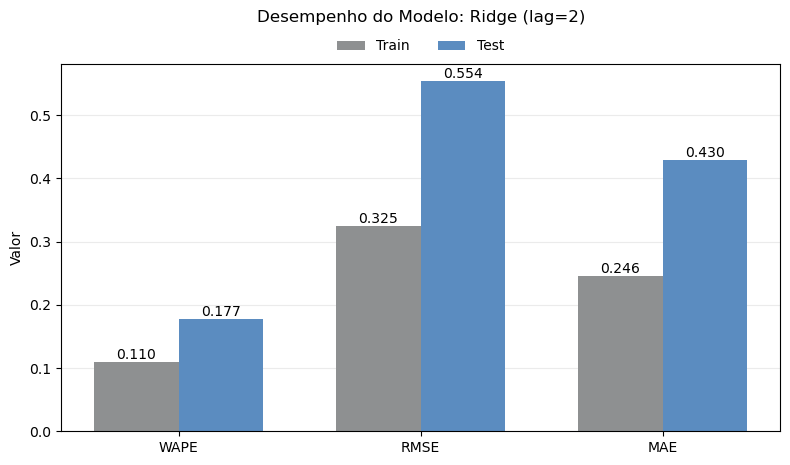

In [34]:
plot_single_model_performance(lag_performance_ranked_df.iloc[0], 'melhor modelo (variáveis computacionais)com lags da alvo')

### Testing the best model

In [35]:
my_lags12 = get_lags(computational_variables, 12)

train, test, preds, models = build_model(computational_variables + my_lags12 + target_lag, 12)
model = models['Ridge']

In [36]:
print("Melhor modelo - Treino")
display(pd.DataFrame(train)[["Ridge"]].T)
print("Melhor modelo - Teste")
display(pd.DataFrame(test)[["Ridge"]].T)

Melhor modelo - Treino


,rmse,mae,wape
Ridge,0.225,0.168,0.076


Melhor modelo - Teste


,rmse,mae,wape
Ridge,0.672,0.544,0.223


In [37]:
preds

{'Ridge': array([3.59106263, 4.13721481, 4.4213379 , 3.67060891, 2.40675558,
        1.93853245, 2.72263511, 3.35911538, 3.1247159 , 3.22350156,
        3.46054025, 4.03009563, 3.3079966 , 2.55607671, 2.04952484,
        2.59108559, 3.01469741, 3.28141759, 3.32128424, 2.80923272,
        2.43275683, 2.2958577 , 2.21828302, 2.35275908, 2.65428466,
        2.62627692, 2.27211615, 2.01156789]),
 'RF - MSE': array([3.939, 3.648, 5.64 , 5.637, 3.978, 1.068, 0.915, 4.31 , 3.899,
        4.237, 4.081, 5.2  , 5.315, 5.025, 1.865, 3.807, 4.278, 4.903,
        5.178, 4.91 , 4.189, 1.885, 3.96 , 4.181, 4.201, 5.085, 4.785,
        3.77 ]),
 'RF - MAE': array([3.788, 3.549, 5.349, 5.3  , 3.582, 0.519, 0.469, 3.607, 3.564,
        3.585, 3.543, 4.318, 4.336, 3.999, 1.736, 3.537, 3.565, 3.979,
        4.243, 3.997, 3.521, 1.747, 3.584, 3.565, 3.517, 4.112, 3.903,
        3.127]),
 'LGBMRegressor': array([2.84212575, 2.64890184, 2.79960158, 3.35749075, 2.62171167,
        1.05383397, 1.49945739, 2.83

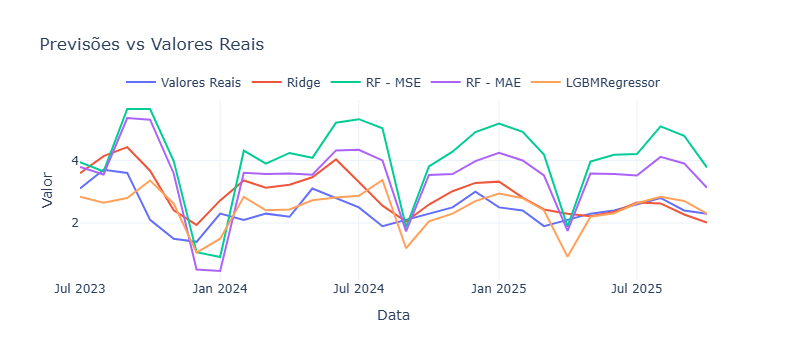

In [38]:
plot_predictions(df_test[target], preds)

In [39]:
importances = dict()

for key, idx in zip(model.feature_names_in_, model.coef_):
    importances[key] = idx

importances = pd.Series(importances)

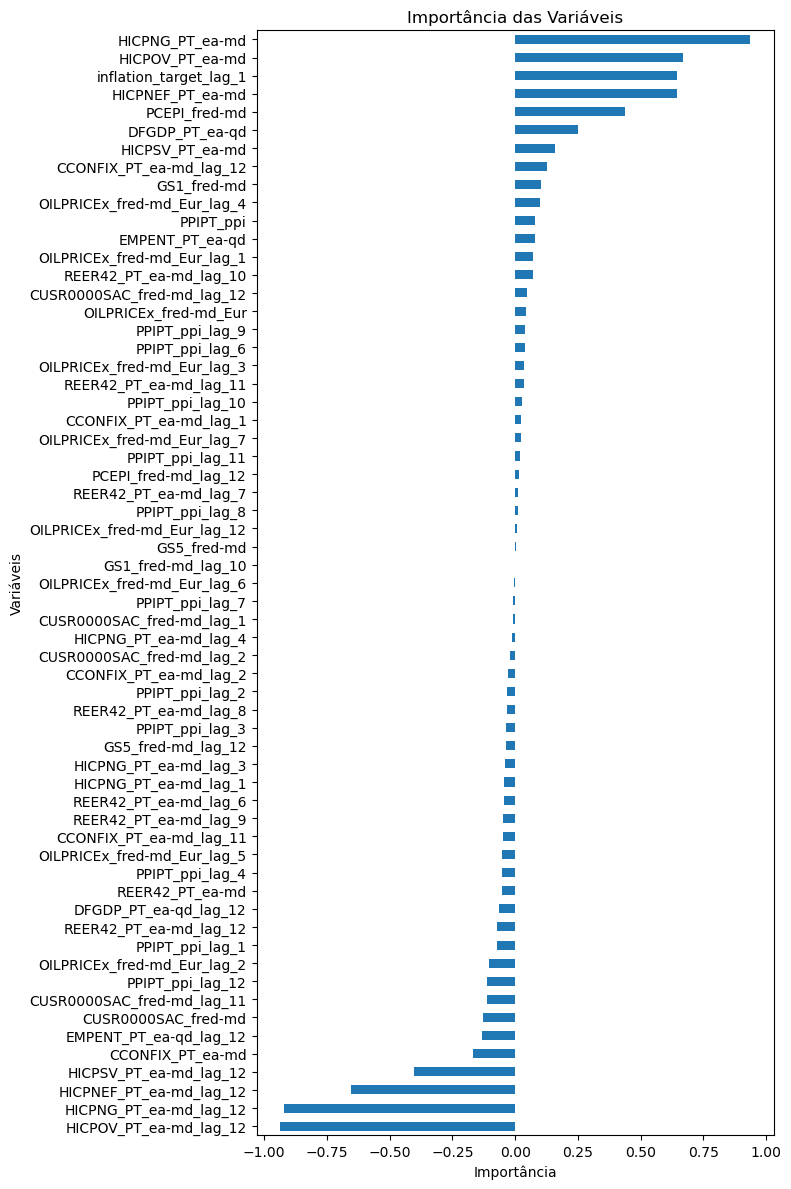

In [40]:
import matplotlib.pyplot as plt

# Ordenar (opcional, mas recomendado)
importances_sorted = importances.sort_values()

plt.figure(figsize=(8, 12))
importances_sorted.plot(kind='barh')  # horizontal fica mais legível

plt.title('Importância das Variáveis')
plt.xlabel('Importância')
plt.ylabel('Variáveis')

plt.tight_layout()
plt.show()

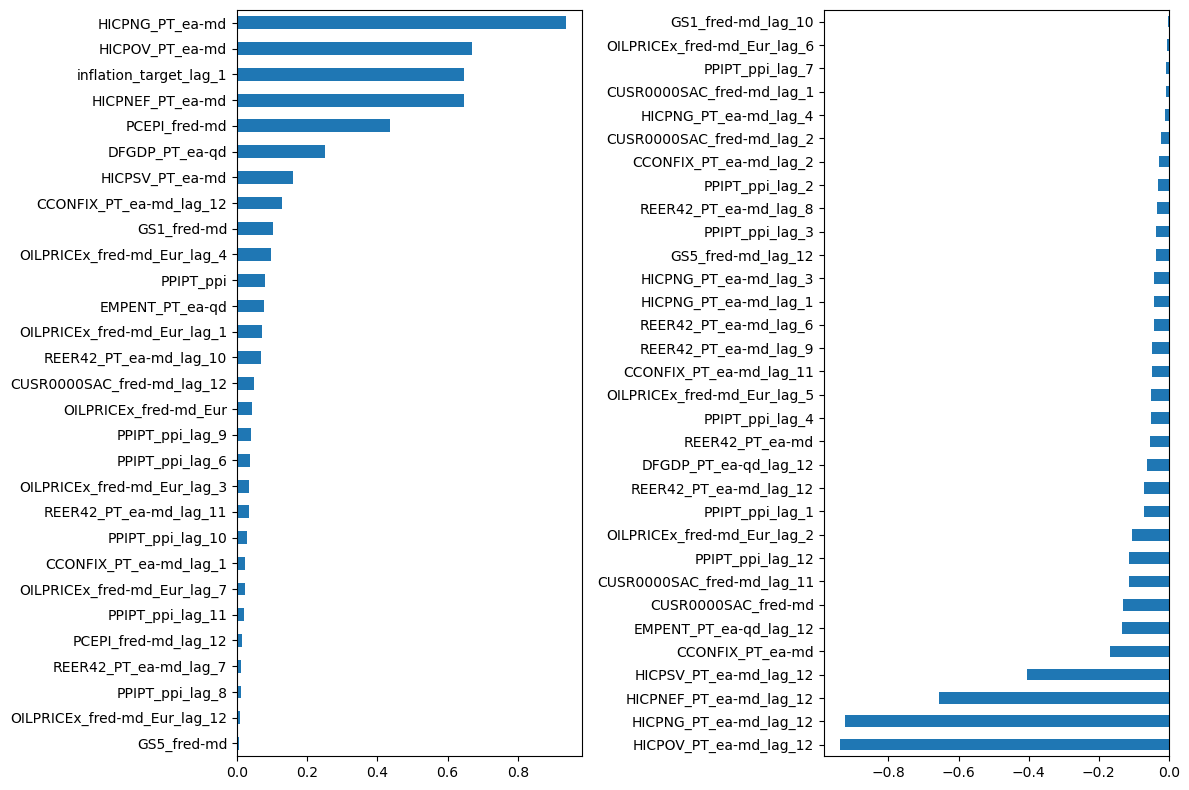

In [41]:
import matplotlib.pyplot as plt

# Ordenar (opcional, mas recomendado)
importances_sorted = importances.sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

importances_sorted.loc[importances_sorted >= 0].plot(kind='barh', ax=ax1)  # horizontal fica mais legível
importances_sorted.loc[importances_sorted < 0].plot(kind='barh', ax=ax2)  # horizontal fica mais legível

# plt.title('Importância das Variáveis')
# plt.xlabel('Importância')
# plt.ylabel('Variáveis')

plt.tight_layout()
plt.show()

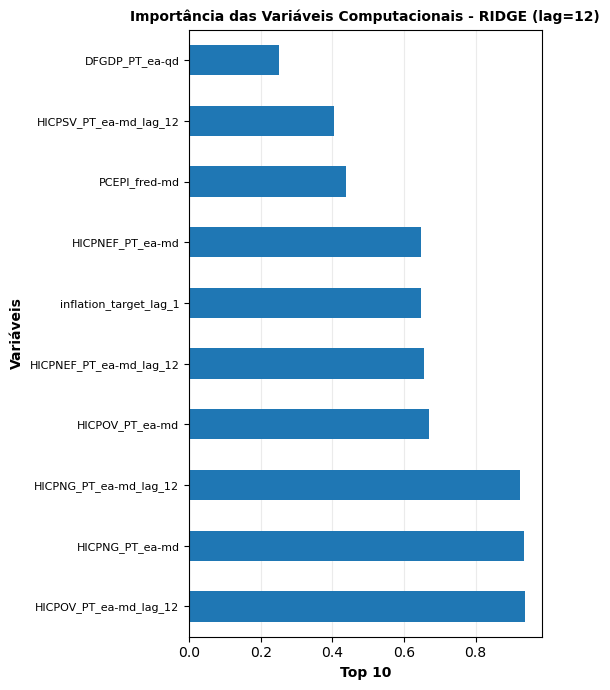

In [42]:
importances_sorted = abs(importances).sort_values(ascending=False).head(10)

plt.figure(figsize=(6, 7))
importances_sorted.head(10).plot(kind='barh')  # horizontal fica mais legível

plt.title('Importância das Variáveis Computacionais - RIDGE (lag=12)', fontdict=dict(fontweight='bold', fontsize=10))
plt.xlabel('Top 10', fontdict=dict(fontweight='bold'))
plt.ylabel('Variáveis', fontdict=dict(fontweight='bold'))

plt.grid(axis="x", alpha=0.25)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.yticks(fontsize=8)
plt.show()

In [43]:
abs(importances).describe()

count    61.000000
mean      0.151689
std       0.243951
min       0.001547
25%       0.028003
50%       0.048800
75%       0.114160
max       0.937267
dtype: float64

In [44]:
new_vars = importances.loc[abs(importances) > 0.05].index

In [45]:
len(new_vars)

30

### Testing the best model with the most important features

In [47]:
train, test, preds, models = build_model(new_vars, 12)
model = models['Ridge']

In [48]:
print("Melhor modelo - Treino")
display(pd.DataFrame(train)[["Ridge"]].T)
print("Melhor modelo - Teste")
display(pd.DataFrame(test)[["Ridge"]].T)

Melhor modelo - Treino


,rmse,mae,wape
Ridge,0.233,0.173,0.078


Melhor modelo - Teste


,rmse,mae,wape
Ridge,0.606,0.492,0.202


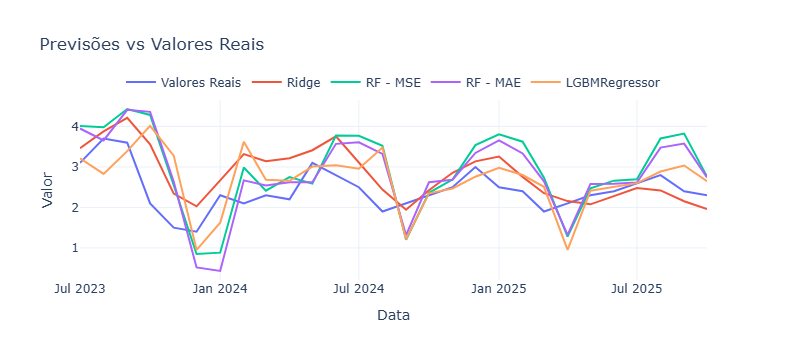

In [49]:
plot_predictions(df_test[target], preds)

# Using all the variables in level

In [50]:
all_columns = [col for col in df_train.columns if '_lag_' not in col and col != target]
all_columns

['PCEPI_fred-md',
 'UNETOT_PT_ea-md',
 'CCI_PT_ea-md',
 'IMPGS_PT_ea-qd',
 'EXPGS_PT_ea-qd',
 'GS5_fred-md',
 'CCONFIX_PT_ea-md',
 'EMPENT_PT_ea-qd',
 'GS1_fred-md',
 'HICPSV_PT_ea-md',
 'HICPNEF_PT_ea-md',
 'HICPOV_PT_ea-md',
 'REER42_PT_ea-md',
 'HICPNG_PT_ea-md',
 'PPIPT_ppi',
 'ULCIN_PT_ea-qd',
 'GDP_PT_ea-qd',
 'CUSR0000SAC_fred-md',
 'epu_pt_epu',
 'DFGDP_PT_ea-qd',
 'OILPRICEx_fred-md_Eur']

In [50]:
train, test, preds, _ = build_model(all_columns)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.727,0.147,0.142,0.200
mae,0.592,0.104,0.103,0.136
wape,0.264,0.047,0.046,0.060


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,3.481,4.343,2.563,2.733
mae,3.275,4.311,2.379,2.668
wape,1.345,1.770,0.977,1.095


In [51]:
plot_predictions(df_test[target], preds)

# Best models using all the variables [without target lag]

In [52]:
lag_performance = {}

for lag in range(1, 13):
    my_lags1 = get_lags(all_columns, lag)
    scores_train, scores_test, preds, _ = build_model(all_columns + my_lags1, lag)

    lag_performance[lag] = {
        "train": scores_train,
        "test": scores_test,
    }

lag_performance_rows = []

for lag, lag_results in lag_performance.items():
    for model_name in lag_results["train"].keys():
        row = {
            "lag": lag,
            "model": model_name,
            "train_wape": lag_results["train"][model_name]["wape"],
            "train_rmse": lag_results["train"][model_name]["rmse"],
            "train_mae": lag_results["train"][model_name]["mae"],
            "test_wape": lag_results["test"][model_name]["wape"],
            "test_rmse": lag_results["test"][model_name]["rmse"],
            "test_mae": lag_results["test"][model_name]["mae"],
        }

        lag_performance_rows.append(row)

lag_performance_df = pd.DataFrame(lag_performance_rows)

print("Primeiros modelos construídos:")
display(lag_performance_df.head(4))

lag_performance_ranked_df = rank_models_by_average_test_rank(lag_performance_df)
print("Top 4 melhores modelos:")
display(lag_performance_ranked_df.head(4))

Primeiros modelos construídos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae
0,1,Ridge,0.265,0.720,0.593,1.444,3.777,3.517
1,1,RF - MSE,0.043,0.128,0.097,1.674,4.162,4.077
2,1,RF - MAE,0.047,0.143,0.106,0.826,2.336,2.012
3,1,LGBMRegressor,0.054,0.191,0.122,1.122,2.820,2.732


Top 4 melhores modelos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae,rank_test_wape,rank_test_rmse,rank_test_mae,Overfitting?,rank_medio
0,11,LGBMRegressor,0.039,0.153,0.087,0.195,0.618,0.474,1.0,1.0,1.0,True,1.0
1,12,LGBMRegressor,0.036,0.142,0.079,0.245,0.724,0.596,2.0,2.0,2.0,True,2.0
2,10,LGBMRegressor,0.041,0.152,0.090,0.269,0.789,0.654,3.0,3.0,3.0,True,3.0
3,12,RF - MSE,0.047,0.137,0.104,0.297,0.820,0.723,4.0,4.0,4.0,True,4.0


## Testing the best model

In [53]:
# train, test, model = build_lag_model4(11)
my_lags1 = get_lags(all_columns, 11)
train, test, preds, models = build_model(all_columns + my_lags1, 11)

# model = models['LGBMRegressor']

In [54]:
lgbm_importance = dict()

for key, idx in zip(models['LGBMRegressor'].feature_name_, models['LGBMRegressor'].feature_importances_):
    lgbm_importance[key] = idx

lgbm_importance = pd.Series(lgbm_importance)
lgbm_importance.sort_values(ascending=False)

PPIPT_ppi                      51
PPIPT_ppi_lag_1                35
OILPRICEx_fred-md_Eur_lag_3    32
OILPRICEx_fred-md_Eur_lag_4    31
PPIPT_ppi_lag_9                30
                               ..
GDP_PT_ea-qd                    3
CCONFIX_PT_ea-md_lag_1          3
CUSR0000SAC_fred-md_lag_1       2
HICPNG_PT_ea-md                 2
CUSR0000SAC_fred-md             2
Length: 64, dtype: int32

In [55]:
print("Melhor modelo - Treino")
display(pd.DataFrame(train)[["LGBMRegressor"]].T)
print("Melhor modelo - Teste")
display(pd.DataFrame(test)[["LGBMRegressor"]].T)

Melhor modelo - Treino


,rmse,mae,wape
LGBMRegressor,0.153,0.087,0.039


Melhor modelo - Teste


,rmse,mae,wape
LGBMRegressor,0.618,0.474,0.195


In [56]:
plot_predictions(df_test[target], preds)

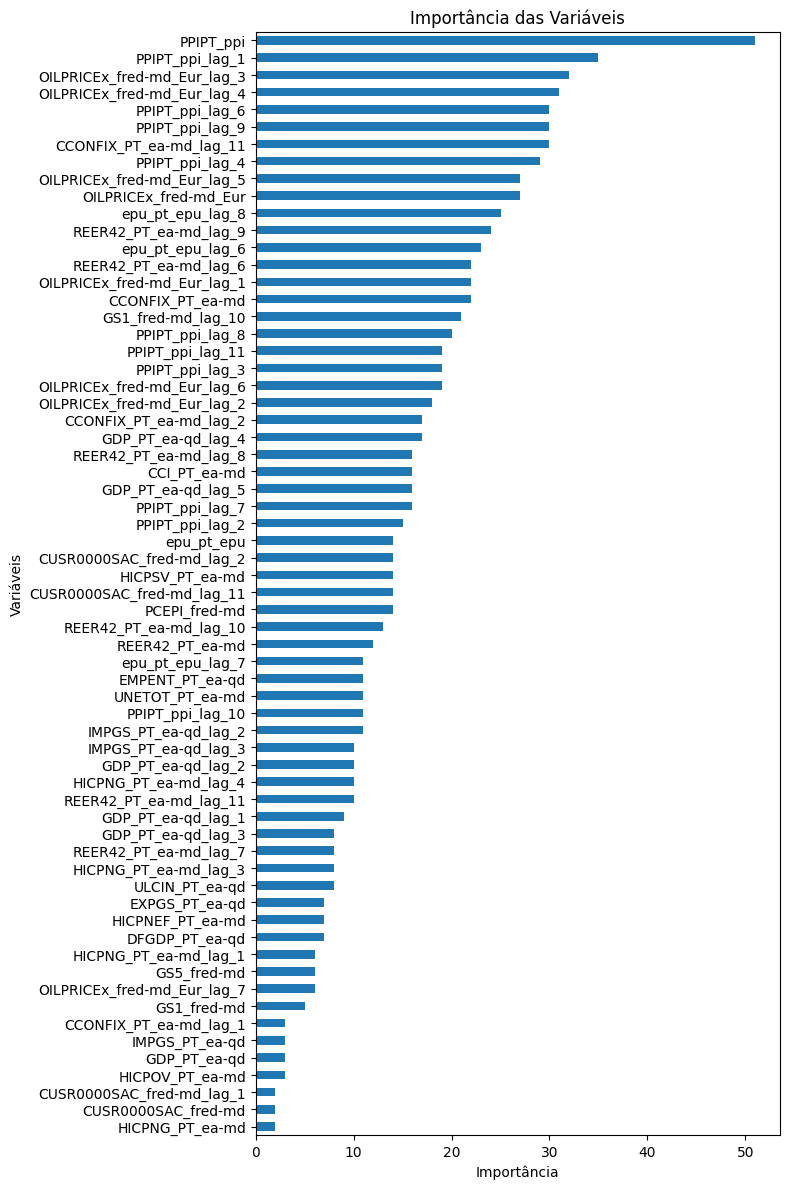

In [57]:
# Ordenar (opcional, mas recomendado)
importances_sorted = lgbm_importance.sort_values()

plt.figure(figsize=(8, 12))
importances_sorted.plot(kind='barh')  # horizontal fica mais legível

plt.title('Importância das Variáveis')
plt.xlabel('Importância')
plt.ylabel('Variáveis')

plt.tight_layout()
plt.show()

# Selecting the best model using all variables with lags [including target lag]

In [58]:
lag_performance = {}

for lag in range(1, 13):
    my_lags1 = get_lags(all_columns, lag)
    scores_train, scores_test, preds, _ = build_model(all_columns + my_lags1 + target_lag, lag)

    lag_performance[lag] = {
        "train": scores_train,
        "test": scores_test,
    }

lag_performance_rows = []

for lag, lag_results in lag_performance.items():
    for model_name in lag_results["train"].keys():
        row = {
            "lag": lag,
            "model": model_name,
            "train_wape": lag_results["train"][model_name]["wape"],
            "train_rmse": lag_results["train"][model_name]["rmse"],
            "train_mae": lag_results["train"][model_name]["mae"],
            "test_wape": lag_results["test"][model_name]["wape"],
            "test_rmse": lag_results["test"][model_name]["rmse"],
            "test_mae": lag_results["test"][model_name]["mae"],
        }

        lag_performance_rows.append(row)

lag_performance_df = pd.DataFrame(lag_performance_rows)

print("Primeiros modelos construídos:")
display(lag_performance_df.head(4))

lag_performance_ranked_df = rank_models_by_average_test_rank(lag_performance_df)
print("Top 4 melhores modelos:")
display(lag_performance_ranked_df.head(4))

Primeiros modelos construídos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae
0,1,Ridge,0.109,0.318,0.245,0.186,0.578,0.453
1,1,RF - MSE,0.046,0.142,0.104,1.255,3.363,3.056
2,1,RF - MAE,0.049,0.153,0.110,1.031,2.684,2.512
3,1,LGBMRegressor,0.055,0.198,0.124,0.392,1.064,0.956


Top 4 melhores modelos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae,rank_test_wape,rank_test_rmse,rank_test_mae,Overfitting?,rank_medio
0,12,Ridge,0.072,0.208,0.160,0.167,0.505,0.407,1.0,1.0,1.0,True,1.000000
1,1,Ridge,0.109,0.318,0.245,0.186,0.578,0.453,3.0,2.0,3.0,False,2.666667
2,11,Ridge,0.100,0.286,0.222,0.185,0.591,0.452,2.0,5.0,2.0,True,3.000000
3,2,Ridge,0.107,0.315,0.240,0.188,0.585,0.459,4.0,3.0,4.0,False,3.666667


## Testing the best model

In [59]:
my_lags1 = get_lags(all_columns, 12)
train, test, preds, models = build_model(all_columns + my_lags1 + target_lag, 12)

In [60]:
lgbm_importance = dict()

for key, idx in zip(models['Ridge'].feature_names_in_, models['Ridge'].coef_):
    lgbm_importance[key] = idx

lgbm_importance = pd.Series(lgbm_importance)
lgbm_importance.sort_values(ascending=False)

HICPNG_PT_ea-md            0.890085
HICPNEF_PT_ea-md           0.718043
HICPOV_PT_ea-md            0.706919
inflation_target_lag_1     0.604726
PCEPI_fred-md              0.355149
                             ...   
EXPGS_PT_ea-qd_lag_12     -0.398425
HICPSV_PT_ea-md_lag_12    -0.447943
HICPNEF_PT_ea-md_lag_12   -0.509866
HICPOV_PT_ea-md_lag_12    -0.803954
HICPNG_PT_ea-md_lag_12    -0.885141
Length: 83, dtype: float64

In [61]:
print("Melhor modelo - Treino")
display(pd.DataFrame(train)[["Ridge"]].T)
print("Melhor modelo - Teste")
display(pd.DataFrame(test)[["Ridge"]].T)

Melhor modelo - Treino


,rmse,mae,wape
Ridge,0.208,0.16,0.072


Melhor modelo - Teste


,rmse,mae,wape
Ridge,0.505,0.407,0.167


In [62]:
plot_predictions(df_test[target], preds, models_to_plot=['Ridge', 'LGBMRegressor'])

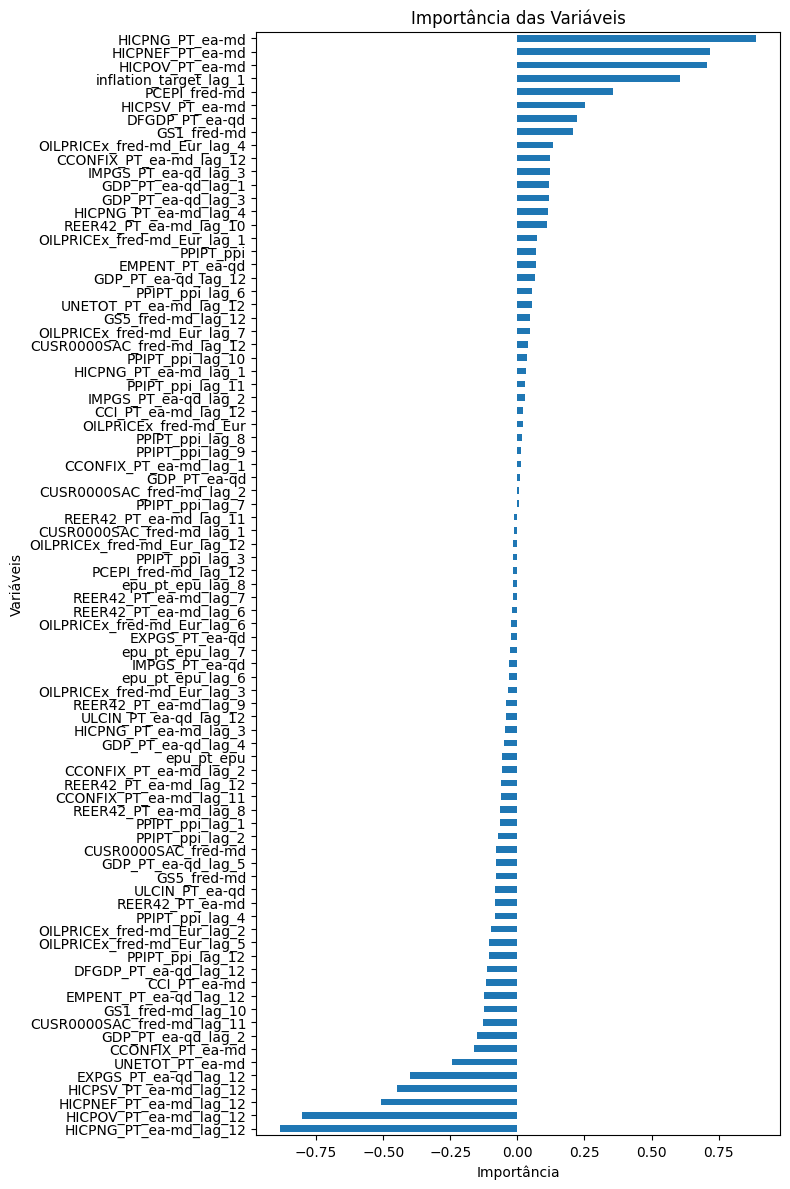

In [63]:
# Ordenar (opcional, mas recomendado)
importances_sorted = lgbm_importance.sort_values()

plt.figure(figsize=(8, 12))
importances_sorted.plot(kind='barh')  # horizontal fica mais legível

plt.title('Importância das Variáveis')
plt.xlabel('Importância')
plt.ylabel('Variáveis')

plt.tight_layout()
plt.show()

# Models with the three first target lags

In [51]:
target_lags = ['inflation_target_lag_1', 'inflation_target_lag_2', 'inflation_target_lag_3']

In [52]:
train, test, preds, _  = build_model(target_lags, 3)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.391,0.205,0.212,0.628
mae,0.295,0.139,0.146,0.356
wape,0.131,0.062,0.065,0.159


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.505,0.498,0.478,0.518
mae,0.379,0.347,0.334,0.394
wape,0.156,0.143,0.137,0.162


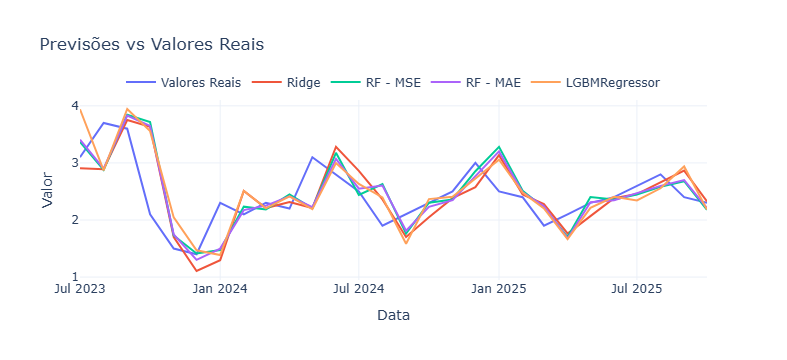

In [53]:
plot_predictions(df_test[target], preds)

## Model with the third target lag

In [67]:
train, test, preds, _  = build_model([target_lags[-1]], 3)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.884,0.657,0.671,0.924
mae,0.614,0.480,0.467,0.637
wape,0.273,0.214,0.208,0.284


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.889,1.103,1.068,0.997
mae,0.649,0.748,0.683,0.673
wape,0.266,0.307,0.281,0.276


In [68]:
plot_predictions(df_test[target], preds)

# Selecting the best model using all variables with lags [including first three target lag]

In [69]:
lag_performance = {}

for lag in range(3, 13):
    my_lags1 = get_lags(all_columns, lag)
    scores_train, scores_test, preds, _ = build_model(all_columns + my_lags1 + target_lags, lag)

    lag_performance[lag] = {
        "train": scores_train,
        "test": scores_test,
    }

lag_performance_rows = []

for lag, lag_results in lag_performance.items():
    for model_name in lag_results["train"].keys():
        row = {
            "lag": lag,
            "model": model_name,
            "train_wape": lag_results["train"][model_name]["wape"],
            "train_rmse": lag_results["train"][model_name]["rmse"],
            "train_mae": lag_results["train"][model_name]["mae"],
            "test_wape": lag_results["test"][model_name]["wape"],
            "test_rmse": lag_results["test"][model_name]["rmse"],
            "test_mae": lag_results["test"][model_name]["mae"],
        }

        lag_performance_rows.append(row)

lag_performance_df = pd.DataFrame(lag_performance_rows)

print("Primeiros modelos construídos:")
display(lag_performance_df.head(4))

lag_performance_ranked_df = rank_models_by_average_test_rank(lag_performance_df)
print("Top 4 melhores modelos:")
display(lag_performance_ranked_df.head(4))

Primeiros modelos construídos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae
0,3,Ridge,0.105,0.311,0.235,0.190,0.581,0.463
1,3,RF - MSE,0.047,0.149,0.105,1.253,3.272,3.052
2,3,RF - MAE,0.049,0.156,0.111,1.021,2.627,2.486
3,3,LGBMRegressor,0.051,0.181,0.114,0.281,0.801,0.685


Top 4 melhores modelos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae,rank_test_wape,rank_test_rmse,rank_test_mae,Overfitting?,rank_medio
0,12,Ridge,0.072,0.207,0.159,0.164,0.483,0.399,1.0,1.0,1.0,True,1.000000
1,11,Ridge,0.099,0.285,0.221,0.189,0.592,0.461,2.0,3.0,2.0,True,2.333333
2,3,Ridge,0.105,0.311,0.235,0.190,0.581,0.463,3.0,2.0,3.0,False,2.666667
3,5,Ridge,0.102,0.307,0.229,0.202,0.614,0.492,4.0,4.0,4.0,True,4.000000


# Model with the most important variables from computacional and teorical variables

In [55]:
my_lags12 = get_lags(computational_variables, 12)

train, test, preds, models = build_model(computational_variables + my_lags12 + target_lag, 12)
model = models['Ridge']

importances = dict()

for key, idx in zip(model.feature_names_in_, model.coef_):
    importances[key] = idx

importances = pd.Series(importances)

new_vars_comp = importances.loc[abs(importances) > 0.25].index
new_vars_teoric = ['PPIPT_ppi', 'CCI_PT_ea-md', 'EXPGS_PT_ea-qd', 'epu_pt_epu_lag_6', 'PPIPT_ppi_lag_1']

print(len(new_vars_comp))
print(len(new_vars_teoric))

9
5


In [56]:
new_vars_comp

Index(['PCEPI_fred-md', 'HICPOV_PT_ea-md', 'HICPNEF_PT_ea-md',
       'HICPNG_PT_ea-md', 'HICPOV_PT_ea-md_lag_12', 'HICPNEF_PT_ea-md_lag_12',
       'HICPSV_PT_ea-md_lag_12', 'HICPNG_PT_ea-md_lag_12',
       'inflation_target_lag_1'],
      dtype='object')

In [57]:
train, test, preds, _  = build_model(new_vars_comp.tolist() + new_vars_teoric, 12)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.257,0.140,0.141,0.220
mae,0.196,0.102,0.103,0.142
wape,0.088,0.046,0.046,0.064


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.363,2.154,1.372,0.616
mae,0.308,1.987,1.251,0.506
wape,0.126,0.816,0.514,0.208


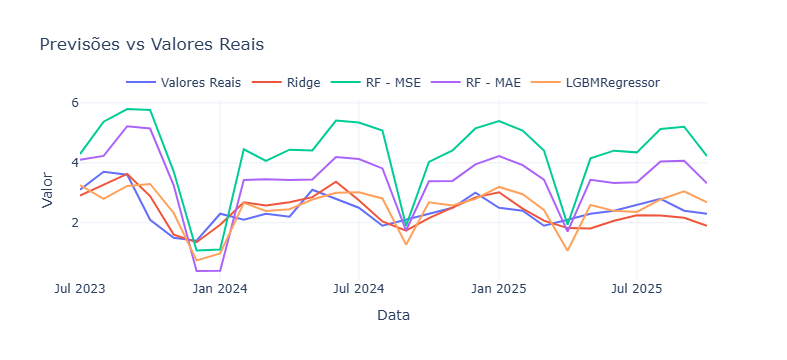

In [58]:
plot_predictions(df_test[target], preds)

In [59]:
model = _['Ridge']
model.feature_names_in_

array(['PCEPI_fred-md', 'HICPOV_PT_ea-md', 'HICPNEF_PT_ea-md',
       'HICPNG_PT_ea-md', 'HICPOV_PT_ea-md_lag_12',
       'HICPNEF_PT_ea-md_lag_12', 'HICPSV_PT_ea-md_lag_12',
       'HICPNG_PT_ea-md_lag_12', 'inflation_target_lag_1', 'PPIPT_ppi',
       'CCI_PT_ea-md', 'EXPGS_PT_ea-qd', 'epu_pt_epu_lag_6',
       'PPIPT_ppi_lag_1'], dtype=object)

In [60]:
best_coefs = pd.Series({key: value for key, value in zip(model.feature_names_in_, model.coef_)})
best_coefs.sort_values(ascending=False)

HICPOV_PT_ea-md            0.872553
HICPNG_PT_ea-md            0.754229
HICPNEF_PT_ea-md           0.720580
inflation_target_lag_1     0.681517
PCEPI_fred-md              0.516889
EXPGS_PT_ea-qd             0.136085
PPIPT_ppi                  0.056416
epu_pt_epu_lag_6          -0.038836
CCI_PT_ea-md              -0.087689
PPIPT_ppi_lag_1           -0.099523
HICPSV_PT_ea-md_lag_12    -0.126467
HICPNG_PT_ea-md_lag_12    -0.915854
HICPNEF_PT_ea-md_lag_12   -0.931730
HICPOV_PT_ea-md_lag_12    -1.117859
dtype: float64

In [61]:
# modelo naive (média)
regression_metrics(df_test[target], np.zeros(df_test.shape[0]) + df_test[target].mean())

{'rmse': np.float64(0.52), 'mae': 0.386, 'wape': np.float64(0.159)}

In [62]:
(0.36 / 0.52) * 100

69.23076923076923

In [63]:
(0.31 / 0.39) * 100

79.48717948717949

In [64]:
df_test[target].mean()

np.float64(2.4357142857142855)

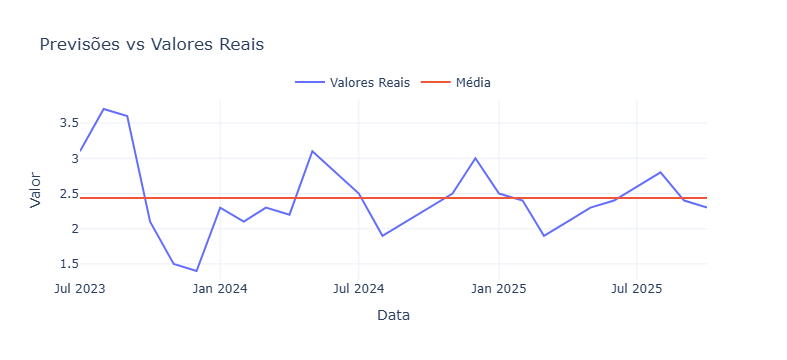

In [65]:
plot_predictions(df_test[target], {'Média': np.zeros(df_test.shape[0]) + df_test[target].mean()})

## Optimizing the best model

In [81]:
# ! pip install optuna

In [66]:
# Python

# Necessary imports
import optuna

In [67]:
X_train = df_train[new_vars_comp.tolist() + new_vars_teoric].iloc[12:]
y_train = df_train[target].iloc[12:]

X_test = df_test[new_vars_comp.tolist() + new_vars_teoric]
y_test = df_test[target]

In [68]:
np.mean([2, 4])

np.float64(3.0)

[I 2026-06-02 19:07:44,120] A new study created in memory with name: no-name-d78ba38e-ecbb-4677-8a2f-0a15886b3bcb
C:\Users\josev\AppData\Local\Temp\ipykernel_41560\3907545563.py:4: FutureWarning:

suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.

[I 2026-06-02 19:07:44,149] Trial 0 finished with value: 0.126 and parameters: {'alpha': 0.8449050819204822}. Best is trial 0 with value: 0.126.
C:\Users\josev\AppData\Local\Temp\ipykernel_41560\3907545563.py:4: FutureWarning:

suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.

[I 2026-06-02 19:07:44,170] Trial 1 finished with value: 0.149 and parameters: {'alpha': 7.372309517204454}. Best is trial 0 with value: 0.126.
C:\Users\josev\AppData\Local\Temp\ipykernel_41560

Best hyperparameters: {'alpha': 0.8449050819204822}
Train


rmse    0.251
mae     0.192
wape    0.087
dtype: float64

Test


rmse    0.364
mae     0.307
wape    0.126
dtype: float64

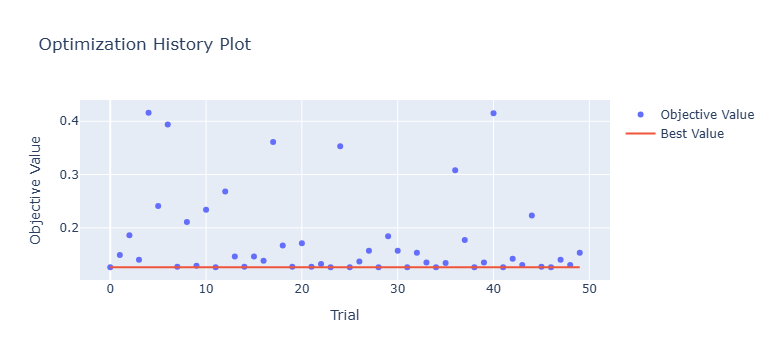

In [76]:
# Define the Optuna objective function
def objective(trial):
    # Suggest hyperparameters for Ridge regression
    alpha = trial.suggest_loguniform('alpha', 1e-3, 100)  # Regularization strength
    
    # Initialize Ridge model with these hyperparameters
    model = Ridge(alpha=alpha, random_state=322)
    
    # Evaluate model using cross-validation
    model.fit(X_train, y_train)

    y_pred = model.predict(X_train)
    rmse_train, mae_train, _ = regression_metrics(y_train, y_pred).values()
    
    y_pred = model.predict(X_test)
    rmse_test, mae_test, _ = regression_metrics(y_test, y_pred).values()
    val_rmse, val_mae, val_wape = regression_metrics(y_test, y_pred).values()
    
    # Optuna minimizes objective by default, so return negative MAE
    return val_wape

# Create Optuna study and optimize
study = optuna.create_study(direction='minimize')  # maximize negative MAE
study.optimize(objective, n_trials=50)

# Print best hyperparameters
print("Best hyperparameters:", study.best_params)

# Train the model with best hyperparameters on the full training set
best_model = Ridge(alpha=study.best_params['alpha'], random_state=322)
best_model.fit(X_train, y_train)

# Evaluate on test set
print("Train")
y_pred = best_model.predict(X_train)
results = regression_metrics(y_train, y_pred)
display(pd.Series(results))
print("Test")
y_pred = best_model.predict(X_test)
results = regression_metrics(y_test, y_pred)
display(pd.Series(results))

# Optional: visualize the optimization history
optuna.visualization.plot_optimization_history(study).show()

[I 2026-06-02 19:09:00,277] A new study created in memory with name: no-name-4b135f89-04f9-403c-a9c6-7edf577329dc
[I 2026-06-02 19:09:00,379] Trial 0 finished with value: 0.491 and parameters: {'n_estimators': 145, 'learning_rate': 0.014308177271867234, 'max_depth': 10, 'num_leaves': 51, 'min_child_samples': 73, 'subsample': 0.5251681700867536, 'colsample_bytree': 0.9962900866569251, 'reg_alpha': 8.043643373241087, 'reg_lambda': 0.000253263452466991}. Best is trial 0 with value: 0.491.
[I 2026-06-02 19:09:00,453] Trial 1 finished with value: 0.652 and parameters: {'n_estimators': 146, 'learning_rate': 0.02641080601532391, 'max_depth': 3, 'num_leaves': 286, 'min_child_samples': 82, 'subsample': 0.9201702002396647, 'colsample_bytree': 0.5250823716571532, 'reg_alpha': 0.001750302050380211, 'reg_lambda': 6.71379539923586}. Best is trial 0 with value: 0.491.
[I 2026-06-02 19:09:00,545] Trial 2 finished with value: 0.425 and parameters: {'n_estimators': 150, 'learning_rate': 0.00189010531095

Best hyperparameters:
{'n_estimators': 472, 'learning_rate': 0.002269262606259645, 'max_depth': 5, 'num_leaves': 264, 'min_child_samples': 35, 'subsample': 0.9373262271460359, 'colsample_bytree': 0.9962232615843662, 'reg_alpha': 0.0025792198003663034, 'reg_lambda': 0.5582922602726863}


rmse    0.468
mae     0.352
wape    0.144
dtype: float64

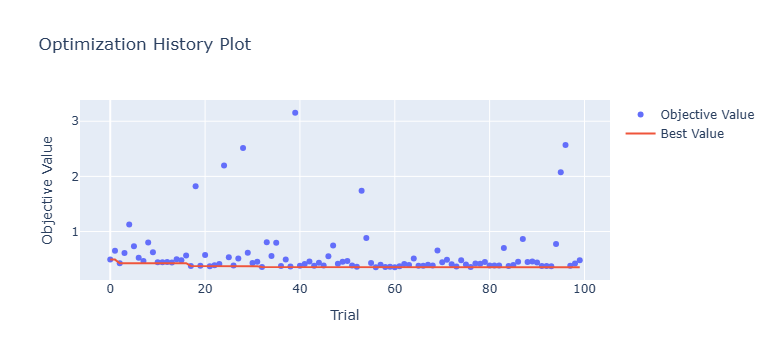

In [77]:
# Define the Optuna objective function
def objective(trial):

    # Hyperparameter search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 10, 300),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state": 322,
        "verbosity": -1
    }

    # Initialize model
    model = LGBMRegressor(**params)

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    rmse, mae, _ = regression_metrics(y_test, y_pred).values()

    # Minimize average error
    return mae


# Create study
study = optuna.create_study(direction="minimize")

# Optimize
study.optimize(objective, n_trials=100)

# Best parameters
print("Best hyperparameters:")
print(study.best_params)

# Train final model
best_model = LGBMRegressor(
    **study.best_params,
    random_state=322,
    verbosity=-1
)

best_model.fit(X_train, y_train)

# Final evaluation
y_pred = best_model.predict(X_test)

results = regression_metrics(y_test, y_pred)

display(pd.Series(results))

# Optimization history
optuna.visualization.plot_optimization_history(study).show()

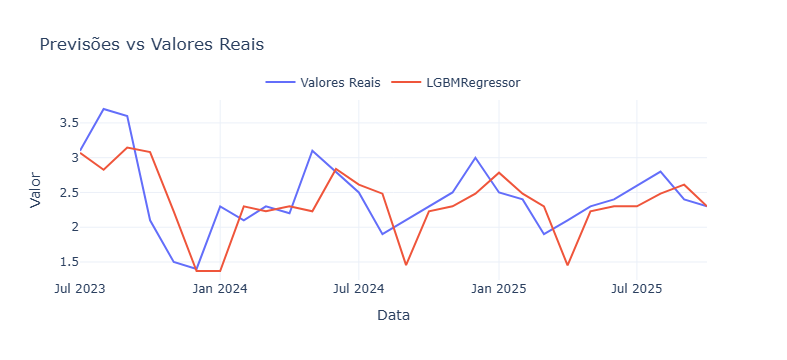

In [78]:
plot_predictions(df_test[target], {'LGBMRegressor': y_pred})